# 02_model_training.ipynb

> Train three prediction models per domain for the variability study
> Models are tuned so that predictive performance is comparable across them,
> ensuring that later differences in explanation content cannot be attributed
> to differences in model accuracy.

[credit] train (22686, 22), test (9723, 22)
[churn] train (4914, 30), test (2107, 30)

[credit] training
  XGBoost
    best CV AUC = 0.9454  (76.7s)
    test AUC = 0.9495, AP = 0.9060
  LightGBM
    best CV AUC = 0.9473  (286.3s)
    test AUC = 0.9508, AP = 0.9086
  RandomForest
    best CV AUC = 0.9320  (634.4s)
    test AUC = 0.9385, AP = 0.8965

[churn] training
  XGBoost
    best CV AUC = 0.8481  (27.4s)
    test AUC = 0.8515, AP = 0.6752
  LightGBM
    best CV AUC = 0.8470  (231.1s)
    test AUC = 0.8507, AP = 0.6795
  RandomForest
    best CV AUC = 0.8442  (140.6s)
    test AUC = 0.8497, AP = 0.6783
Domain  AUC min  AUC max  Spread  Tolerance  Parity met
credit   0.9385   0.9508  0.0123       0.02        True
 churn   0.8497   0.8515  0.0018       0.02        True

Parity after re-tuning:
Domain  AUC min  AUC max  Spread  Tolerance  Parity met
credit   0.9385   0.9508  0.0123       0.02        True
 churn   0.8497   0.8515  0.0018       0.02        True
Saved: model_credit_XGBoos

,Domain,Model,CV AUC,Test AUC,Test AP,Brier
0,credit,XGBoost,0.9454,0.9495,0.9060,0.0523
1,credit,LightGBM,0.9473,0.9508,0.9086,0.0513
2,credit,RandomForest,0.9320,0.9385,0.8965,0.0549
3,churn,XGBoost,0.8481,0.8515,0.6752,0.1325
4,churn,LightGBM,0.8470,0.8507,0.6795,0.1327
5,churn,RandomForest,0.8442,0.8497,0.6783,0.1332


Saved: fig03_roc_curves.png / fig03_roc_curves.pdf


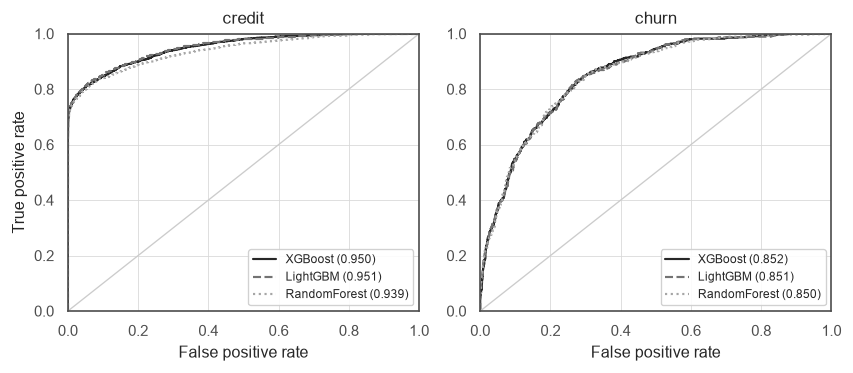

Saved: fig04_auc_parity.png / fig04_auc_parity.pdf


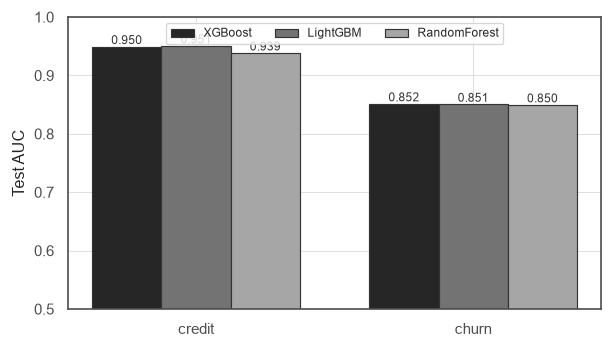

Saved: fig05_calibration.png / fig05_calibration.pdf


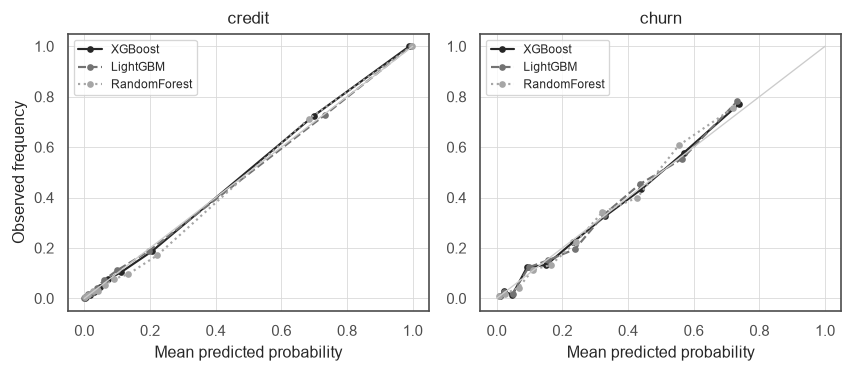

Saved: fig06_probability_distributions.png / fig06_probability_distributions.pdf


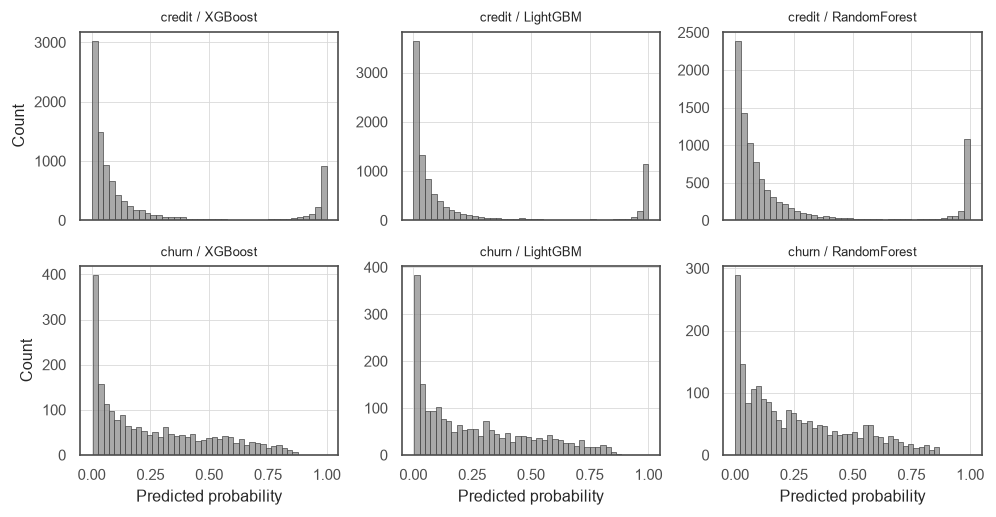

Saved: tab04_cross_model_agreement.csv


,Domain,Pair,Pearson r,Spearman rho,Mean abs diff
0,credit,XGBoost vs LightGBM,0.9895,0.9715,0.0254
1,credit,XGBoost vs RandomForest,0.9795,0.8781,0.0410
2,credit,LightGBM vs RandomForest,0.9734,0.8572,0.0464
3,churn,XGBoost vs LightGBM,0.9966,0.9961,0.0136
4,churn,XGBoost vs RandomForest,0.9855,0.9828,0.0305
5,churn,LightGBM vs RandomForest,0.9861,0.9826,0.0291


Saved: logs/02_run_20260911.json
Model artefacts:
  model_churn_LightGBM.joblib                 949.0 KB
  model_churn_RandomForest.joblib           14413.8 KB
  model_churn_XGBoost.joblib                  445.1 KB
  model_credit_LightGBM.joblib               2694.1 KB
  model_credit_RandomForest.joblib         165766.3 KB
  model_credit_XGBoost.joblib                1287.2 KB

Outputs:
  results\figures\fig03_roc_curves.pdf
  results\figures\fig03_roc_curves.png
  results\figures\fig04_auc_parity.pdf
  results\figures\fig04_auc_parity.png
  results\figures\fig05_calibration.pdf
  results\figures\fig05_calibration.png
  results\figures\fig06_probability_distributions.pdf
  results\figures\fig06_probability_distributions.png
  results\tables\tab02_model_performance.csv
  results\tables\tab03_auc_parity_check.csv
  results\tables\tab04_cross_model_agreement.csv

Next step: 03_attribution.ipynb


In [1]:
# ============================================================================
# 02_model_training.ipynb
# Train three prediction models per domain for the variability study
# Models are tuned so that predictive performance is comparable across them,
# ensuring that later differences in explanation content cannot be attributed
# to differences in model accuracy.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})

# Line styles distinguish models without relying on colour
LINE_STYLES = {"XGBoost": "-", "LightGBM": "--", "RandomForest": ":"}
GRAY_LEVELS = {"XGBoost": "0.15", "LightGBM": "0.45", "RandomForest": "0.65"}


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Study configuration
DOMAINS = ["credit", "churn"]
MODEL_NAMES = ["XGBoost", "LightGBM", "RandomForest"]

# Performance parity requirement.
# The study design requires the three models to reach a similar AUC so that
# explanation variability is not confounded by predictive quality.
AUC_TOLERANCE = 0.02      # maximum acceptable spread across the three models
N_SEARCH_ITER = 40        # randomised search budget per model
CV_FOLDS = 4


# [Cell 4] Load processed data
def load_split(domain):
    """Load the fixed train/test split produced in 01_data_prep."""
    out = {}
    for key in ["X_train", "X_test", "y_train", "y_test"]:
        df = pd.read_parquet(DATA_DIR / f"{domain}_{key}.parquet")
        out[key] = df.iloc[:, 0] if key.startswith("y") else df
    print(f"[{domain}] train {out['X_train'].shape}, test {out['X_test'].shape}")
    return out


data = {d: load_split(d) for d in DOMAINS}

with open(DATA_DIR / "feature_registry.json", encoding="utf-8") as f:
    feature_registry = json.load(f)


# [Cell 5] Hyperparameter search spaces
# Ranges are deliberately wide so that the search can find configurations
# reaching comparable AUC across the three model families.
SEARCH_SPACES = {
    "XGBoost": {
        "n_estimators": [200, 400, 600, 800],
        "learning_rate": [0.01, 0.02, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6, 8],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "min_child_weight": [1, 3, 5, 8],
        "reg_lambda": [0.5, 1.0, 2.0, 5.0],
        "gamma": [0.0, 0.1, 0.3],
    },
    "LightGBM": {
        "n_estimators": [200, 400, 600, 800],
        "learning_rate": [0.01, 0.02, 0.05, 0.1],
        "num_leaves": [15, 31, 63, 127],
        "max_depth": [-1, 4, 6, 8],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "min_child_samples": [10, 20, 40, 60],
        "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    },
    "RandomForest": {
        "n_estimators": [300, 500, 800],
        "max_depth": [6, 10, 14, 20, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "max_features": ["sqrt", "log2", 0.5],
    },
}


def build_estimator(name):
    """Instantiate an untuned classifier for the given model family."""
    if name == "XGBoost":
        return xgb.XGBClassifier(
            random_state=SEED, n_jobs=-1, eval_metric="logloss",
            tree_method="hist", verbosity=0,
        )
    if name == "LightGBM":
        return lgb.LGBMClassifier(
            random_state=SEED, n_jobs=-1, verbose=-1,
        )
    if name == "RandomForest":
        return RandomForestClassifier(
            random_state=SEED, n_jobs=-1,
        )
    raise ValueError(f"Unknown model: {name}")


# [Cell 6] Training routine
def tune_and_fit(name, X_train, y_train):
    """Randomised search with stratified cross-validation, then refit."""
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(
        estimator=build_estimator(name),
        param_distributions=SEARCH_SPACES[name],
        n_iter=N_SEARCH_ITER,
        scoring="roc_auc",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0
    print(f"    best CV AUC = {search.best_score_:.4f}  ({elapsed:.1f}s)")
    return search.best_estimator_, search.best_params_, search.best_score_


def evaluate(model, X_test, y_test):
    """Compute discrimination, ranking and calibration metrics on the test set."""
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "AUC": roc_auc_score(y_test, proba),
        "AP": average_precision_score(y_test, proba),
        "Brier": brier_score_loss(y_test, proba),
    }, proba


# [Cell 7] Train all models for all domains
models = {}
predictions = {}
records = []

for domain in DOMAINS:
    print(f"\n{'=' * 60}\n[{domain}] training\n{'=' * 60}")
    sp = data[domain]
    models[domain] = {}
    predictions[domain] = {}

    for name in MODEL_NAMES:
        print(f"  {name}")
        est, params, cv_auc = tune_and_fit(name, sp["X_train"], sp["y_train"])
        metrics, proba = evaluate(est, sp["X_test"], sp["y_test"])

        models[domain][name] = est
        predictions[domain][name] = proba

        records.append({
            "Domain": domain,
            "Model": name,
            "CV AUC": round(cv_auc, 4),
            "Test AUC": round(metrics["AUC"], 4),
            "Test AP": round(metrics["AP"], 4),
            "Brier": round(metrics["Brier"], 4),
            "Params": json.dumps(params),
        })
        print(f"    test AUC = {metrics['AUC']:.4f}, AP = {metrics['AP']:.4f}")

perf = pd.DataFrame(records)


# [Cell 8] Performance parity check
# The design requires the three models to be comparable in predictive quality.
# If the AUC spread exceeds the tolerance, the weaker models are re-tuned with
# a larger search budget before proceeding.
def parity_report(perf_df):
    """Report the AUC spread across models within each domain."""
    rows = []
    for domain in DOMAINS:
        sub = perf_df[perf_df["Domain"] == domain]
        spread = sub["Test AUC"].max() - sub["Test AUC"].min()
        rows.append({
            "Domain": domain,
            "AUC min": sub["Test AUC"].min(),
            "AUC max": sub["Test AUC"].max(),
            "Spread": round(spread, 4),
            "Tolerance": AUC_TOLERANCE,
            "Parity met": spread <= AUC_TOLERANCE,
        })
    return pd.DataFrame(rows)


parity = parity_report(perf)
print(parity.to_string(index=False))

for _, r in parity.iterrows():
    if not r["Parity met"]:
        print(
            f"\nWARNING [{r['Domain']}]: AUC spread {r['Spread']:.4f} exceeds "
            f"tolerance {AUC_TOLERANCE}. Increase N_SEARCH_ITER for the weaker "
            f"models, or report the residual gap as a limitation."
        )


# [Cell 9] Optional re-tuning for parity
# Runs only when parity is not met. Raises the search budget for models whose
# AUC falls below the domain maximum by more than the tolerance.
RETUNE_ITER = 120

for domain in DOMAINS:
    sub = perf[perf["Domain"] == domain]
    best_auc = sub["Test AUC"].max()
    lagging = sub[sub["Test AUC"] < best_auc - AUC_TOLERANCE]["Model"].tolist()

    if not lagging:
        continue

    print(f"\n[{domain}] re-tuning: {lagging}")
    sp = data[domain]
    _saved = N_SEARCH_ITER
    globals()["N_SEARCH_ITER"] = RETUNE_ITER

    for name in lagging:
        est, params, cv_auc = tune_and_fit(name, sp["X_train"], sp["y_train"])
        metrics, proba = evaluate(est, sp["X_test"], sp["y_test"])

        models[domain][name] = est
        predictions[domain][name] = proba

        mask = (perf["Domain"] == domain) & (perf["Model"] == name)
        perf.loc[mask, ["CV AUC", "Test AUC", "Test AP", "Brier", "Params"]] = [
            round(cv_auc, 4), round(metrics["AUC"], 4),
            round(metrics["AP"], 4), round(metrics["Brier"], 4),
            json.dumps(params),
        ]
        print(f"    revised test AUC = {metrics['AUC']:.4f}")

    globals()["N_SEARCH_ITER"] = _saved

parity = parity_report(perf)
print("\nParity after re-tuning:")
print(parity.to_string(index=False))


# [Cell 10] Persist models and predictions
for domain in DOMAINS:
    for name, est in models[domain].items():
        path = DATA_DIR / f"model_{domain}_{name}.joblib"
        joblib.dump(est, path)
        print(f"Saved: {path.name}")

pred_frames = []
for domain in DOMAINS:
    sp = data[domain]
    frame = pd.DataFrame({"y_true": sp["y_test"].values})
    frame.insert(0, "case_id", np.arange(len(frame)))
    frame.insert(0, "domain", domain)
    for name in MODEL_NAMES:
        frame[f"proba_{name}"] = predictions[domain][name]
    pred_frames.append(frame)

pred_all = pd.concat(pred_frames, ignore_index=True)
pred_all.to_parquet(DATA_DIR / "test_predictions.parquet", index=False)
print(f"Saved: test_predictions.parquet  ({len(pred_all):,} rows)")


# [Cell 11] Tables for the paper
perf_out = perf.drop(columns=["Params"])
save_table(perf_out, "tab02_model_performance")
save_table(parity, "tab03_auc_parity_check")

# Hyperparameters are logged separately rather than placed in the paper tables
hyper_log = {
    f"{r['Domain']}_{r['Model']}": json.loads(r["Params"])
    for _, r in perf.iterrows()
}
with open(LOG_DIR / "02_hyperparameters.json", "w", encoding="utf-8") as f:
    json.dump(hyper_log, f, ensure_ascii=False, indent=2)
print("Saved: logs/02_hyperparameters.json")

display(perf_out)


# [Cell 12] Figure: ROC curves by domain
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

for ax, domain in zip(axes, DOMAINS):
    y_test = data[domain]["y_test"]
    for name in MODEL_NAMES:
        fpr, tpr, _ = roc_curve(y_test, predictions[domain][name])
        auc = perf[(perf["Domain"] == domain) & (perf["Model"] == name)]["Test AUC"].iloc[0]
        ax.plot(
            fpr, tpr,
            linestyle=LINE_STYLES[name], color=GRAY_LEVELS[name],
            linewidth=1.3, label=f"{name} ({auc:.3f})",
        )
    ax.plot([0, 1], [0, 1], color="0.8", linewidth=0.8, linestyle="-")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate" if domain == DOMAINS[0] else "")
    ax.set_title(domain, fontsize=10, color="0.15")
    ax.legend(loc="lower right", fontsize=7, frameon=True, framealpha=0.9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
save_fig(fig, "fig03_roc_curves")
plt.show()


# [Cell 13] Figure: AUC parity across models
fig, ax = plt.subplots(figsize=(5.2, 3.0))

x = np.arange(len(DOMAINS))
width = 0.25

for i, name in enumerate(MODEL_NAMES):
    vals = [
        perf[(perf["Domain"] == d) & (perf["Model"] == name)]["Test AUC"].iloc[0]
        for d in DOMAINS
    ]
    ax.bar(
        x + (i - 1) * width, vals, width,
        color=GRAY_LEVELS[name], edgecolor="0.2", linewidth=0.7,
        label=name,
    )
    for xi, v in zip(x + (i - 1) * width, vals):
        ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7, color="0.2")

ax.set_xticks(x)
ax.set_xticklabels(DOMAINS)
ax.set_ylabel("Test AUC")
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=7, frameon=True, ncol=3, loc="upper center")

plt.tight_layout()
save_fig(fig, "fig04_auc_parity")
plt.show()


# [Cell 14] Figure: calibration curves
# Calibration is reported because explanation narratives frequently reference
# predicted probabilities; poorly calibrated models would distort that framing.
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

for ax, domain in zip(axes, DOMAINS):
    y_test = data[domain]["y_test"]
    for name in MODEL_NAMES:
        frac_pos, mean_pred = calibration_curve(
            y_test, predictions[domain][name], n_bins=10, strategy="quantile"
        )
        ax.plot(
            mean_pred, frac_pos,
            linestyle=LINE_STYLES[name], color=GRAY_LEVELS[name],
            linewidth=1.3, marker="o", markersize=3, label=name,
        )
    ax.plot([0, 1], [0, 1], color="0.8", linewidth=0.8)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency" if domain == DOMAINS[0] else "")
    ax.set_title(domain, fontsize=10, color="0.15")
    ax.legend(fontsize=7, frameon=True, loc="upper left")

plt.tight_layout()
save_fig(fig, "fig05_calibration")
plt.show()


# [Cell 15] Figure: predicted probability distributions
# The spread of predicted probabilities determines how many cases sit near a
# decision boundary, which matters for case sampling in 03_attribution.
fig, axes = plt.subplots(2, 3, figsize=(8.4, 4.4), sharex=True)

for r, domain in enumerate(DOMAINS):
    for c, name in enumerate(MODEL_NAMES):
        ax = axes[r, c]
        sns.histplot(
            predictions[domain][name], bins=40, ax=ax,
            color="0.55", edgecolor="0.25", linewidth=0.4,
        )
        ax.set_title(f"{domain} / {name}", fontsize=8, color="0.15")
        ax.set_xlabel("Predicted probability" if r == 1 else "")
        ax.set_ylabel("Count" if c == 0 else "")

plt.tight_layout()
save_fig(fig, "fig06_probability_distributions")
plt.show()


# [Cell 16] Cross-model agreement on predicted probabilities
# Recorded because low agreement between models would itself explain part of
# the explanation-content variability observed in later blocks.
agree_rows = []
for domain in DOMAINS:
    for i, a in enumerate(MODEL_NAMES):
        for b in MODEL_NAMES[i + 1:]:
            pa, pb = predictions[domain][a], predictions[domain][b]
            agree_rows.append({
                "Domain": domain,
                "Pair": f"{a} vs {b}",
                "Pearson r": round(float(np.corrcoef(pa, pb)[0, 1]), 4),
                "Spearman rho": round(
                    float(pd.Series(pa).corr(pd.Series(pb), method="spearman")), 4
                ),
                "Mean abs diff": round(float(np.mean(np.abs(pa - pb))), 4),
            })

agreement = pd.DataFrame(agree_rows)
save_table(agreement, "tab04_cross_model_agreement")
display(agreement)


# [Cell 17] Run log for reproducibility
run_log = {
    "notebook": "02_model_training",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED


        
    "test_size": 0.30,
    "cv_folds": CV_FOLDS,
    "n_search_iter": N_SEARCH_ITER,
    "auc_tolerance": AUC_TOLERANCE,
    "library_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "xgboost": xgb.__version__,
        "lightgbm": lgb.__version__,
    },
    "performance": perf.drop(columns=["Params"]).to_dict(orient="records"),
    "parity": parity.to_dict(orient="records"),
}

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"02_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/02_run_{stamp}.json")


# [Cell 18] Verification
print("Model artefacts:")
for p in sorted(DATA_DIR.glob("model_*.joblib")):
    print(f"  {p.name:<40} {p.stat().st_size / 1024:>8.1f} KB")

print("\nOutputs:")
for p in sorted(FIG_DIR.glob("fig0[3-6]*")) + sorted(TAB_DIR.glob("tab0[2-4]*")):
    print(f"  {p.relative_to(ROOT)}")

print("\nNext step: 03_attribution.ipynb")